# hw3: Обучение без учителя

*Спасибо ещё одному великому курсу mlcourse.ai и авторам: Ольга Дайховская (@aiho в Slack ODS), Юрий Кашницкий (@yorko в Slack ODS).*

### О задании

В этом задании мы разберемся с тем, как работают методы снижения размерности и кластеризации данных. Заодно еще раз попрактикуемся в
задаче классификации.

Мы будем работать с набором данных [Samsung Human Activity Recognition](https://archive.ics.uci.edu/ml/datasets/Human+Activity+Recognition+Using+Smartphones). Данные поступают с акселерометров и гироскопов мобильных телефонов Samsung Galaxy S3 (подробнее про признаки – по ссылке на UCI выше), также известен вид активности человека с телефоном в кармане – ходил ли он, стоял, лежал, сидел или шел вверх/вниз по лестнице.

Вначале мы представим, что вид активности нам неизвестнен, и попробуем кластеризовать людей чисто на основе имеющихся признаков. Затем решим задачу определения вида физической активности именно как задачу классификации.

**Заполните код в клетках (где написано "Ваш код здесь") и ответьте на вопросы, выделив ответ полужирным** (``` **выделить двойными звёздочками** ```).

### Оценивание и штрафы
Вам необходимо ответить на 10 вопросов и выполнить 2 задания. Каждое из заданий и вопросов имеет определенную «стоимость» (указана в скобках). Максимально допустимая оценка за работу — 10 баллов. Неэффективная и/или неоригинальная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Заполненный ноутбук ```hw3-unsupervised.ipynb``` необходимо загрузить на свой Github. Затем нужно оставить комментарий в Google-таблице с оценками в столбце "hw3" в строке со своей фамилией о том, что вы выполнили работу и оставить ссылку на ноутбук.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm_notebook

%matplotlib inline
from matplotlib import pyplot as plt

plt.style.use(['seaborn-v0_8-darkgrid'])
plt.rcParams['figure.figsize'] = (12, 9)
plt.rcParams['font.family'] = 'DejaVu Sans'

from sklearn import metrics
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

RANDOM_STATE = 17

In [2]:
X_train = np.loadtxt("datasets/UCI_HAR/train/X_train.txt")
y_train = np.loadtxt("datasets/UCI_HAR/train/y_train.txt").astype(int)

X_test = np.loadtxt("datasets/UCI_HAR/test/X_test.txt")
y_test = np.loadtxt("datasets/UCI_HAR/test/y_test.txt").astype(int)

In [3]:

assert(X_train.shape == (7352, 561) and y_train.shape == (7352,))
assert(X_test.shape == (2947, 561) and y_test.shape == (2947,))

Для кластеризации нам не нужен вектор ответов, поэтому будем работать с объединением обучающей и тестовой выборок. Объедините *X_train* с *X_test*, а *y_train* – с *y_test*.

In [4]:
# Ваш код здесь
X = np.concatenate((X_train, X_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)
print("Размерность X:", X.shape)
print("Размерность y:", y.shape)

Размерность X: (10299, 561)
Размерность y: (10299,)


Определим число уникальных значений меток целевого класса.

In [5]:
np.unique(y)

array([1, 2, 3, 4, 5, 6])

In [31]:
n_classes = np.unique(y).size
n_classes

6

[Эти метки соответствуют:](https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.names)
- 1 - ходьбе
- 2 - подъему вверх по лестнице
- 3 - спуску по лестнице
- 4 - сидению
- 5 - стоянию
- 6 - лежанию

*уж простите, если звучание этих существительных кажется корявым :)*

Отмасштабируйте выборку с помощью `StandardScaler` с параметрами по умолчанию.

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Понижаем размерность с помощью PCA, оставляя столько компонент, сколько нужно для того, чтобы объяснить как минимум 90% дисперсии исходных (отмасштабированных) данных. Используйте отмасштабированную выборку и зафиксируйте random_state (константа RANDOM_STATE).

In [7]:
# Ваш код здесь
from sklearn.decomposition import PCA
pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

**Вопрос 1:** (1 балл)

Какое минимальное число главных компонент нужно выделить, чтобы объяснить 90% дисперсии исходных (отмасштабированных) данных?

**Варианты:**
- 56
- 65 ✅
- 66
- 193

In [9]:
# Ваш код здесь
print(pca.n_components_)

65


**Вопрос 2:** (0.5 баллов)

Сколько процентов дисперсии приходится на первую главную компоненту? Округлите до целых процентов.

**Варианты:**
- 45
- 51 ✅
- 56
- 61

In [10]:
# Ваш код здесь
first_pc_variance = pca.explained_variance_ratio_[0]
print(round(first_pc_variance * 100))

51


Визуализируйте данные в проекции на первые две главные компоненты.

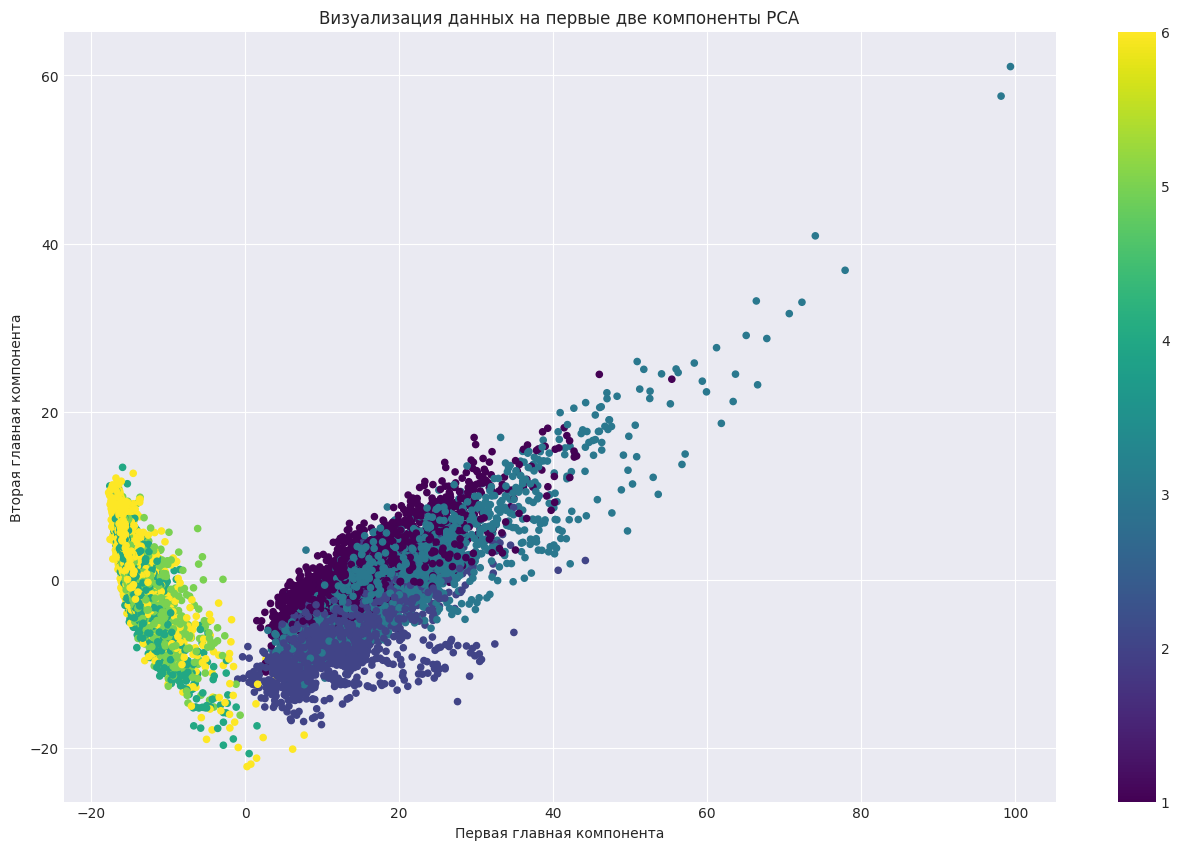

In [11]:
# Ваш код здесь
plt.figure(figsize=(16, 10))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=20, cmap='viridis')
cbar = plt.colorbar(ticks=[1, 2, 3, 4, 5, 6])
plt.title("Визуализация данных на первые две компоненты PCA")
plt.xlabel("Первая главная компонента")
plt.ylabel("Вторая главная компонента")
plt.show()

**Вопрос 3:** (0.5 баллов)

Если все получилось правильно, Вы увидите сколько-то кластеров, почти идеально отделенных друг от друга. Какие виды активности входят в эти кластеры?<br>

**Ответ:**
- 1 кластер: все 6 активностей
- 2 кластера: (ходьба, подъем вверх по лестнице, спуск по лестнице) и (сидение, стояние, лежание)  ✅
- 3 кластера: (ходьба), (подъем вверх по лестнице, спуск по лестнице) и (сидение, стояние, лежание)
- 6 кластеров

------------------------------

**Задание 1.** (1 балл)

Сделайте кластеризацию данных методом `KMeans` (собственная имплементация и готовая реализация), обучив модель на данных со сниженной за счет PCA размерностью. В данном случае мы подскажем, что нужно искать именно 6 кластеров, но в общем случае мы не будем знать, сколько кластеров надо искать.

Параметры:

- **n_clusters** = n_classes (число уникальных меток целевого класса)
- **n_init** = 100
- **random_state** = RANDOM_STATE (для воспроизводимости результата)

Остальные параметры со значениями по умолчанию.

In [8]:
# Ваш код здесь
class MyKMeans:
    def __init__(self, n_clusters=3, n_init=10, max_iter=300, random_state=None):
        self.n_clusters = n_clusters
        self.n_init = n_init
        self.max_iter = max_iter
        self.random_state = random_state

        self.cluster_centers_ = None
        self.labels_ = None
        self.inertia_ = np.inf

    def fit(self, X):
        if self.random_state is not None:
            np.random.seed(self.random_state)

        best_inertia = np.inf
        best_centers = None
        best_labels = None

        for _ in range(self.n_init):

            random_idx = np.random.permutation(X.shape[0])[:self.n_clusters]
            centroids = X[random_idx]

            for i in range(self.max_iter):
                distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)

                labels = np.argmin(distances, axis=1)

                # Шаг пересчета
                new_centroids = np.array([
                    X[labels == k].mean(axis=0) if np.sum(labels == k) > 0 else centroids[k]
                    for k in range(self.n_clusters)
                ])

                # Проверка на сходимость
                if np.allclose(centroids, new_centroids):
                    break

                centroids = new_centroids


            closest_dist = np.min(distances, axis=1)
            current_inertia = np.sum(closest_dist ** 2)

            if current_inertia < best_inertia:
                best_inertia = current_inertia
                best_centers = centroids
                best_labels = labels

        self.inertia_ = best_inertia
        self.cluster_centers_ = best_centers
        self.labels_ = best_labels

        return self

    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.cluster_centers_, axis=2)
        return np.argmin(distances, axis=1)

In [9]:
my_kmeans = MyKMeans(n_clusters=6, n_init=100, random_state=RANDOM_STATE)
my_kmeans.fit(X_pca)
print(f"MyKMeans inertia: {my_kmeans.inertia_:.2f}")

MyKMeans inertia: 2003454.20


In [10]:
from sklearn.cluster import KMeans

sk_kmeans = KMeans(n_clusters=6, n_init=100, random_state=RANDOM_STATE)
sk_kmeans.fit(X_pca)
print(f"Sklearn inertia: {sk_kmeans.inertia_:.2f}")

Sklearn inertia: 2003454.90


In [11]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(sk_kmeans.labels_, my_kmeans.labels_)
print(f"\nS сходство разбиений (ARI): {ari:.4f}")


S сходство разбиений (ARI): 0.9987


Визуализируйте данные в проекции на первые две главные компоненты. Раскрасьте точки в соответствии с полученными метками кластеров.

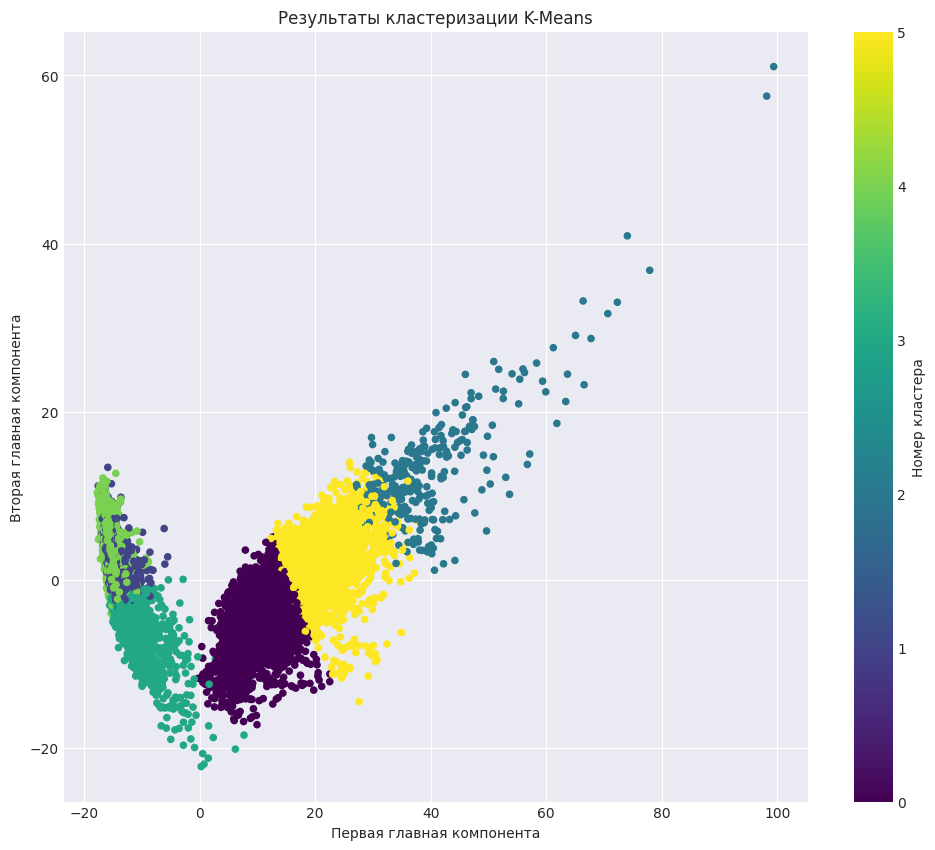

In [12]:
# Ваш код здесь
plt.figure(figsize=(12, 10))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=my_kmeans.labels_, s=20, cmap='viridis')

plt.title("Результаты кластеризации K-Means")
plt.xlabel("Первая главная компонента")
plt.ylabel("Вторая главная компонента")
plt.colorbar(label='Номер кластера')
plt.show()

Посмотрите на соответствие между метками кластеров и исходными метками классов и на то, какие виды активностей алгоритм `KMeans` путает.

In [13]:
tab = pd.crosstab(y, my_kmeans.labels_, margins=True)
tab.index = ['ходьба', 'подъем вверх по лестнице',
             'спуск по лестнице', 'сидение', 'стояние', 'лежание', 'все']
tab.columns = ['cluster' + str(i + 1) for i in range(6)] + ['все']
tab

,cluster1,cluster2,cluster3,cluster4,cluster5,cluster6,все
ходьба,901,0,78,0,0,743,1722
подъем вверх по лестнице,1239,0,5,2,0,298,1544
спуск по лестнице,319,0,196,0,0,891,1406
сидение,1,1235,0,450,91,0,1777
стояние,0,1344,0,562,0,0,1906
лежание,5,52,0,329,1558,0,1944
все,2465,2631,279,1343,1649,1932,10299


Видим, что каждому классу (т.е. каждой активности) соответствуют несколько кластеров. Давайте посмотрим на максимальную долю объектов в классе, отнесенных к какому-то одному кластеру. Это будет простой метрикой, характеризующей, насколько легко класс отделяется от других при кластеризации.

Пример: если для класса "спуск по лестнице", в котором 1406 объектов,  распределение кластеров такое:
 - кластер 1 – 900
 - кластер 3 – 500
 - кластер 6 – 6,

то такая доля будет 900 / 1406 $\approx$ 0.64.


**Вопрос 4:** (1 балл)

Какой вид активности отделился от остальных лучше всего в терминах простой  метрики, описанной выше?<br>

**Ответ:**
- ходьба
- стояние
- спуск по лестнице
- перечисленные варианты не подходят ✅

Активности, которые есть:
- Ходьба: 901 / 1722 ~ 0.52
- Спуск по лестнице: 891 / 1406 ~ 0.63
- Стояние: 1344 / 1906 ~ 0.7

Которых нет:
- Подъем по лестнице: 1239 / 1544 ~ 0.8
- Лежание: 1558 / 1944 ~ 0.8

Видно, что kMeans не очень хорошо отличает только активности друг от друга. Используйте метод локтя, чтобы выбрать оптимальное количество кластеров. Параметры алгоритма и данные используем те же, что раньше, меняем только `n_clusters`.

In [14]:
from tqdm.notebook import tqdm
# Ваш код здесь
inertia = []
for k in tqdm(range(1, n_classes + 1)):
    kmeans = MyKMeans(n_clusters=k, n_init=100, random_state=RANDOM_STATE)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)


  0%|          | 0/6 [00:00<?, ?it/s]

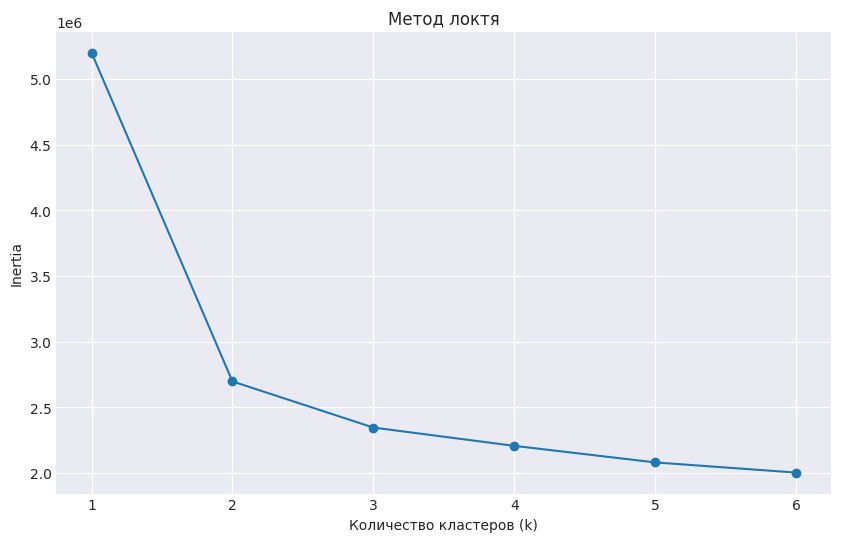

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_classes + 1), inertia, marker='o')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Inertia')
plt.title('Метод локтя')
plt.grid(True)
plt.show()

**Вопрос 5:** (1 балл)

Какое количество кластеров оптимально выбрать, согласно методу локтя?<br>

**Ответ:**
- 1
- 2 ✅
- 3
- 4

------------------------

Попробуем еще один метод кластеризации, который описывался в статье – агломеративную кластеризацию.

In [16]:
ag = AgglomerativeClustering(n_clusters=n_classes,
                             linkage='ward').fit(X_pca)

Посчитайте Adjusted Rand Index (`sklearn.metrics`) для получившегося разбиения на кластеры и для `KMeans` с параметрами из задания к 4 вопросу.

In [17]:
# Ваш код здесь
ari = adjusted_rand_score(ag.labels_, my_kmeans.labels_)
print(f"\nS сходство разбиений(MY) (ARI): {ari:.4f}")

ari_sk = adjusted_rand_score(ag.labels_, sk_kmeans.labels_)
print(f"\nS сходство разбиений(SK) (ARI): {ari_sk:.4f}")


S сходство разбиений(MY) (ARI): 0.6923

S сходство разбиений(SK) (ARI): 0.6915


**Вопрос 6:** (1 балл)

Отметьте все верные утверждения.<br>

**Варианты:**
- Согласно ARI, KMeans справился с кластеризацией хуже, чем Agglomerative Clustering
- Для ARI не имеет значения какие именно метки присвоены кластерам, имеет значение только разбиение объектов на кластеры ✅
- В случае случайного разбиения на кластеры ARI будет близок к нулю ✅

-------------------------------

Можно заметить, что задача не очень хорошо решается именно как задача кластеризации, если выделять несколько кластеров (> 2). Давайте теперь решим задачу классификации, вспомнив, что данные у нас размечены.  

Для классификации используйте метод опорных векторов – класс `sklearn.svm.LinearSVC`. Мы в курсе отдельно не рассматривали этот алгоритм, но он очень известен, почитать про него можно, например, в материалах Евгения Соколова –  [тут](https://github.com/esokolov/ml-course-msu/blob/master/ML16/lecture-notes/Sem11_linear.pdf).

Настройте для `LinearSVC` гиперпараметр `C` с помощью `GridSearchCV`.

- Обучите новый `StandardScaler` на обучающей выборке (со всеми исходными признаками), прмиените масштабирование к тестовой выборке
- В `GridSearchCV` укажите  cv=3.

In [18]:
# Ваш код здесь

new_scaler = StandardScaler()
X_train_scaled = new_scaler.fit_transform(X_train)
X_test_scaled = new_scaler.transform(X_test)

In [19]:
svc = LinearSVC(random_state=RANDOM_STATE)
svc_params = {'C': [0.001, 0.01, 0.1, 1, 10]}

grid_search  = GridSearchCV(svc, svc_params, cv=3, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=3, estimator=LinearSVC(random_state=17), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10]})

In [20]:
# Ваш код здесь
best_svc = grid_search.best_estimator_
print("Лучший параметр C:", grid_search.best_params_['C'])
print("Лучшая точность (CV score):", grid_search.best_score_)

Лучший параметр C: 0.1
Лучшая точность (CV score): 0.9381145554917194


**Вопрос 7** (0.5 баллов)

Какое значение гиперпараметра `C` было выбрано лучшим по итогам кросс-валидации?<br>

**Ответ:**
- 0.001
- 0.01
- 0.1  ✅
- 1
- 10

In [21]:
y_predicted = best_svc.predict(X_test_scaled)

In [22]:
tab = pd.crosstab(y_test, y_predicted, margins=True)
tab.index = ['ходьба', 'подъем вверх по лестнице', 'спуск по лестнице',
             'сидение', 'стояние', 'лежание', 'все']
tab.columns = tab.index
tab

,ходьба,подъем вверх по лестнице,спуск по лестнице,сидение,стояние,лежание,все
ходьба,494,2,0,0,0,0,496
подъем вверх по лестнице,12,459,0,0,0,0,471
спуск по лестнице,2,4,413,1,0,0,420
сидение,0,4,0,427,60,0,491
стояние,0,0,0,15,517,0,532
лежание,0,0,0,0,11,526,537
все,508,469,413,443,588,526,2947


**Вопрос 8:** (0.5 балл)

Какой вид активности SVM определяет хуже всего в терминах точности? Полноты? <br>

**Ответ:**
- по точности – подъем вверх по лестнице, по полноте – лежание
- по точности – лежание, по полноте – сидение
- по точности – ходьба, по полноте – ходьба
- по точности – сидение, по полноте – стояние
- по точности – стояние, по полноте – сидение ✅

In [23]:
precision = {}
recall = {}
for i in range(6):
    activity_name = ['ходьба', 'подъем вверх по лестнице', 'спуск по лестнице', 'сидение', 'стояние', 'лежание'][i]
    tp = tab.iloc[i, i]
    fp = tab.iloc[6, i] - tp
    fn = tab.iloc[i, 6] - tp
    
    precision[activity_name] = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall[activity_name] = tp / (tp + fn) if (tp + fn) > 0 else 0

print("Точность (Precision):")
for activity, prec in precision.items():
    print(f"{activity}: {prec:.4f}")

print("\nПолнота (Recall):")
for activity, rec in recall.items():
    print(f"{activity}: {rec:.4f}")

worst_precision = min(precision, key=precision.get)
worst_recall = min(recall, key=recall.get)
print(f"\nХуже всего по точности: {worst_precision} ({precision[worst_precision]:.4f})")
print(f"Худе всего по полноте: {worst_recall} ({recall[worst_recall]:.4f})")

Точность (Precision):
ходьба: 0.9724
подъем вверх по лестнице: 0.9787
спуск по лестнице: 1.0000
сидение: 0.9639
стояние: 0.8793
лежание: 1.0000

Полнота (Recall):
ходьба: 0.9960
подъем вверх по лестнице: 0.9745
спуск по лестнице: 0.9833
сидение: 0.8697
стояние: 0.9718
лежание: 0.9795

Хуже всего по точности: стояние (0.8793)
Худе всего по полноте: сидение (0.8697)


Наконец, проделайте то же самое, что в 7 вопросе, только добавив PCA.

- Используйте выборки `X_train_scaled` и `X_test_scaled`
- Обучите тот же PCA, что раньше, на отмасшабированной обучающей выборке, примените преобразование к тестовой
- Настройте гиперпараметр `C` на кросс-валидации по обучающей выборке с PCA-преобразованием. Вы заметите, насколько это проходит быстрее, чем раньше.

**Вопрос 9:** (1 балл)

Какова разность между лучшим качеством (долей верных ответов) на кросс-валидации в случае всех 561 исходных признаков и во втором случае, когда применялся метод главных компонент? Округлите до целых процентов.<br>

**Варианты:**
- Качество одинаковое
- 2%
- 4% ✅
- 10%
- 20%

In [24]:
pca2 = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_train_pca = pca2.fit_transform(X_train_scaled)
X_test_pca = pca2.transform(X_test_scaled)

In [25]:
svc_pca = LinearSVC(random_state=RANDOM_STATE)
svc_params_pca = {'C': [0.001, 0.01, 0.1, 1, 10]}

grid_search_pca = GridSearchCV(svc_pca, svc_params_pca, cv=3, n_jobs=-1)
grid_search_pca.fit(X_train_pca, y_train)

GridSearchCV(cv=3, estimator=LinearSVC(random_state=17), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10]})

In [26]:
print("Лучший параметр C (с PCA):", grid_search_pca.best_params_['C'])
print("Лучшая точность с PCA (CV score):", grid_search_pca.best_score_)
print("Лучшая точность без PCA (CV score):", grid_search.best_score_)

diff_percent = round((grid_search.best_score_ - grid_search_pca.best_score_) * 100)
print(f"Разность: {diff_percent}%")

Лучший параметр C (с PCA): 0.1
Лучшая точность с PCA (CV score): 0.8983982658750974
Лучшая точность без PCA (CV score): 0.9381145554917194
Разность: 4%


**Вопрос 10:** (1 балл)

Выберите все верные утверждения:

**Варианты:**
- Метод главных компонент в данном случае позволил уменьшить время обучения модели, при этом качество (доля верных ответов на кросс-валидации) очень пострадало, более чем на 10%
- PCA можно использовать для визуализации данных, однако для этой задачи есть и лучше подходящие методы, например, tSNE. Зато PCA имеет меньшую вычислительную сложность ✅
- PCA строит линейные комбинации исходных признаков, и в некоторых задачах они могут плохо интерпретироваться человеком ✅

**Задание 2.** (1 балл)

Попробуйте использовать DBSCAN в качестве алгоритма кластеризации и метод понижения размерности tSNE.

In [27]:
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN

tsne = TSNE(n_components=2, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_scaled[:1000])

In [28]:
dbscan = DBSCAN(eps=3, min_samples=10)
clusters_dbscan = dbscan.fit_predict(X_tsne)

print(f"Число кластеров: {len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)}")
print(f"Число шумовых точек: {list(clusters_dbscan).count(-1)}")

Число кластеров: 15
Число шумовых точек: 65


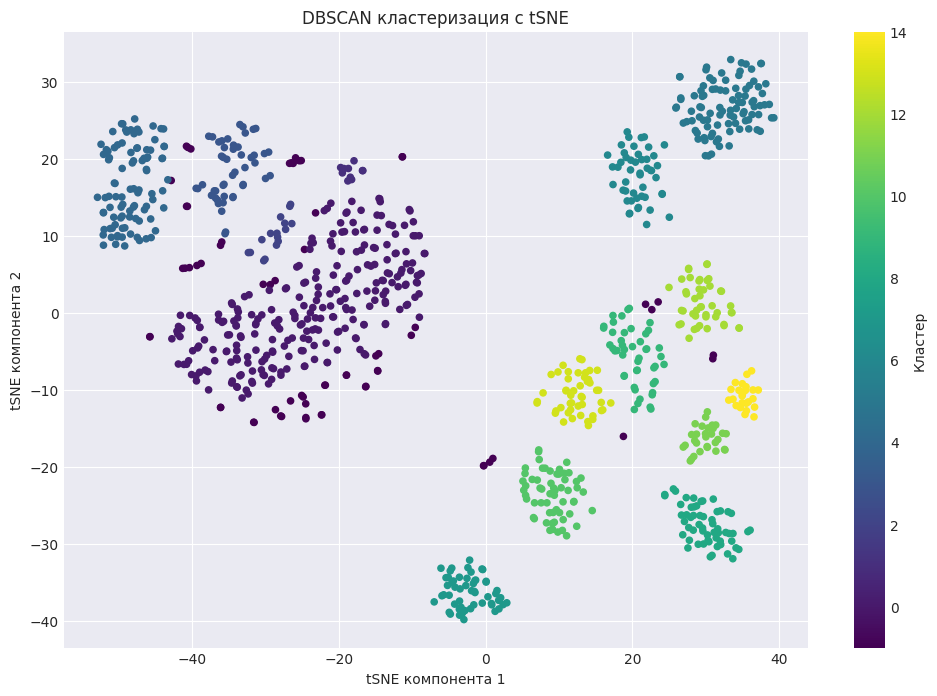

In [29]:
plt.figure(figsize=(12, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters_dbscan, s=20, cmap='viridis')
plt.title("DBSCAN кластеризация с tSNE")
plt.xlabel("tSNE компонента 1")
plt.ylabel("tSNE компонента 2")
plt.colorbar(label='Кластер')
plt.show()

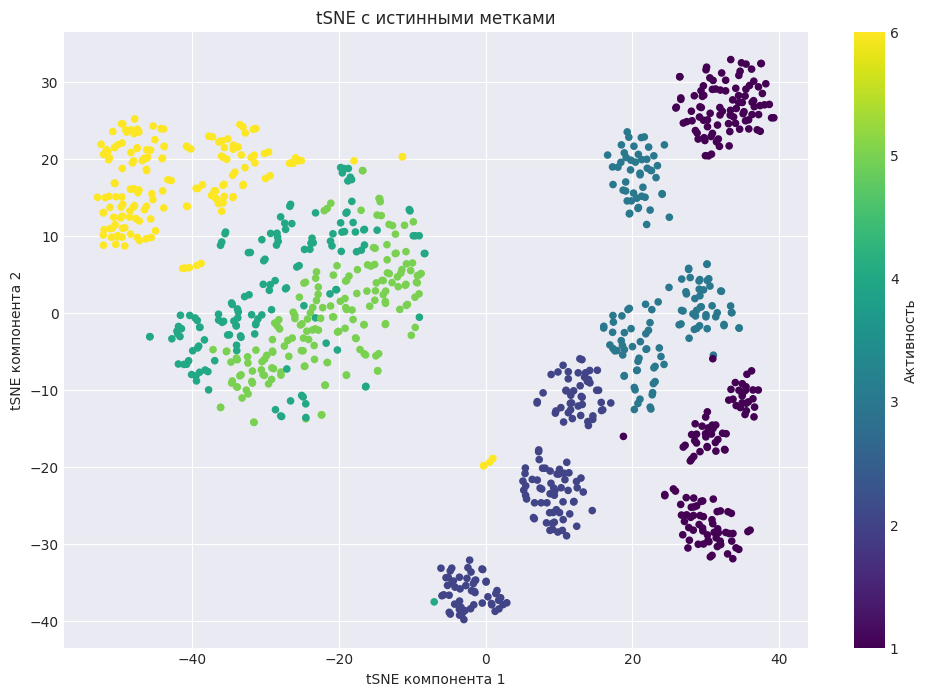

In [30]:
plt.figure(figsize=(12, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y[:1000], s=20, cmap='viridis')
plt.title("tSNE с истинными метками")
plt.xlabel("tSNE компонента 1")
plt.ylabel("tSNE компонента 2")
plt.colorbar(label='Активность')
plt.show()